In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('StudentsPerformance.csv')

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.shape

(1000, 8)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**conclusion 1 Average marks of all the subjects is between 66 to 68**

In [10]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


<Axes: >

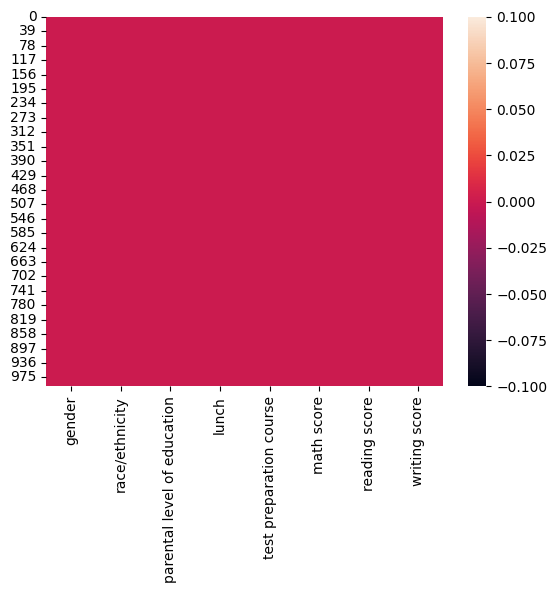

In [13]:
sns.heatmap(df.isnull())

In [16]:
df['Total_score']=df['math score']+df['reading score']+df['writing score']
df['Average']=df['Total_score']/3

In [17]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [22]:
df['Total_score'].groupby(df['gender']).mean()

,Total_score
gender,
female,208.708494
male,197.512448


conclusion 2 average total marks score by female is 208 and male by is 197 so female score more than male

In [24]:
df.nunique()

,0
gender,2
race/ethnicity,5
parental level of education,6
lunch,2
test preparation course,2
math score,81
reading score,72
writing score,77
Total_score,194
Average,194


**Extract categorical features and numerical features**

In [33]:
categorical_feature=[feature for feature in df.columns if df[feature].dtype=='O']
numerical_feature=[feature for feature in df.columns if df[feature].dtype!='O']

<Axes: xlabel='Average', ylabel='Count'>

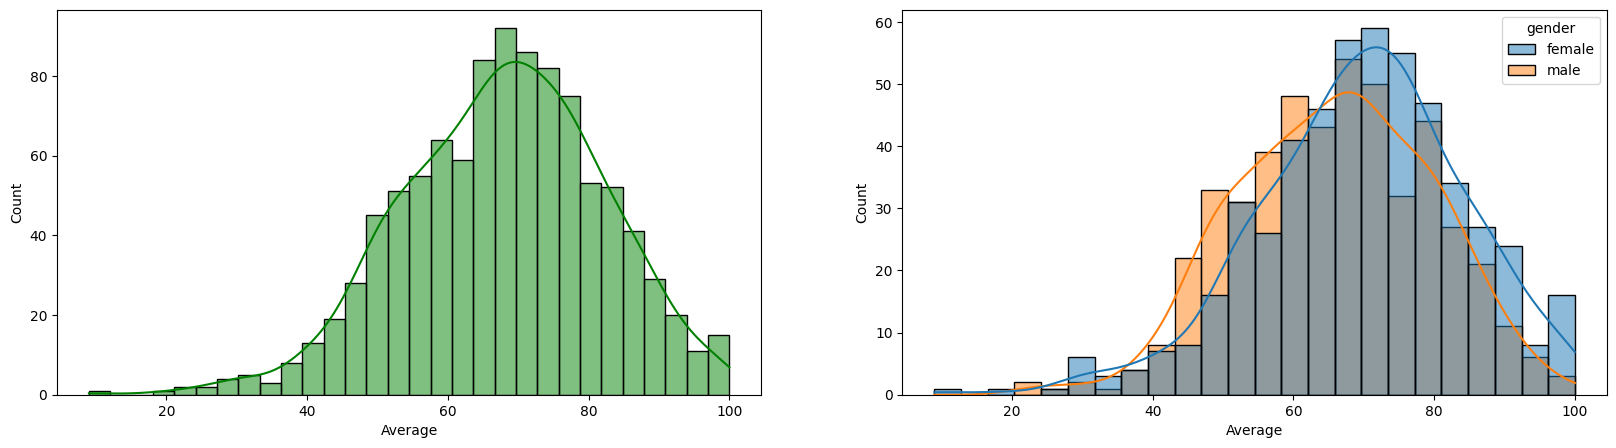

In [41]:
# find histplot
fig,axis=plt.subplots(1,2,figsize=(20,5))
plt.subplot(121)

sns.histplot(data=df,x='Average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average',hue='gender',kde=True)

<Axes: xlabel='Average', ylabel='Count'>

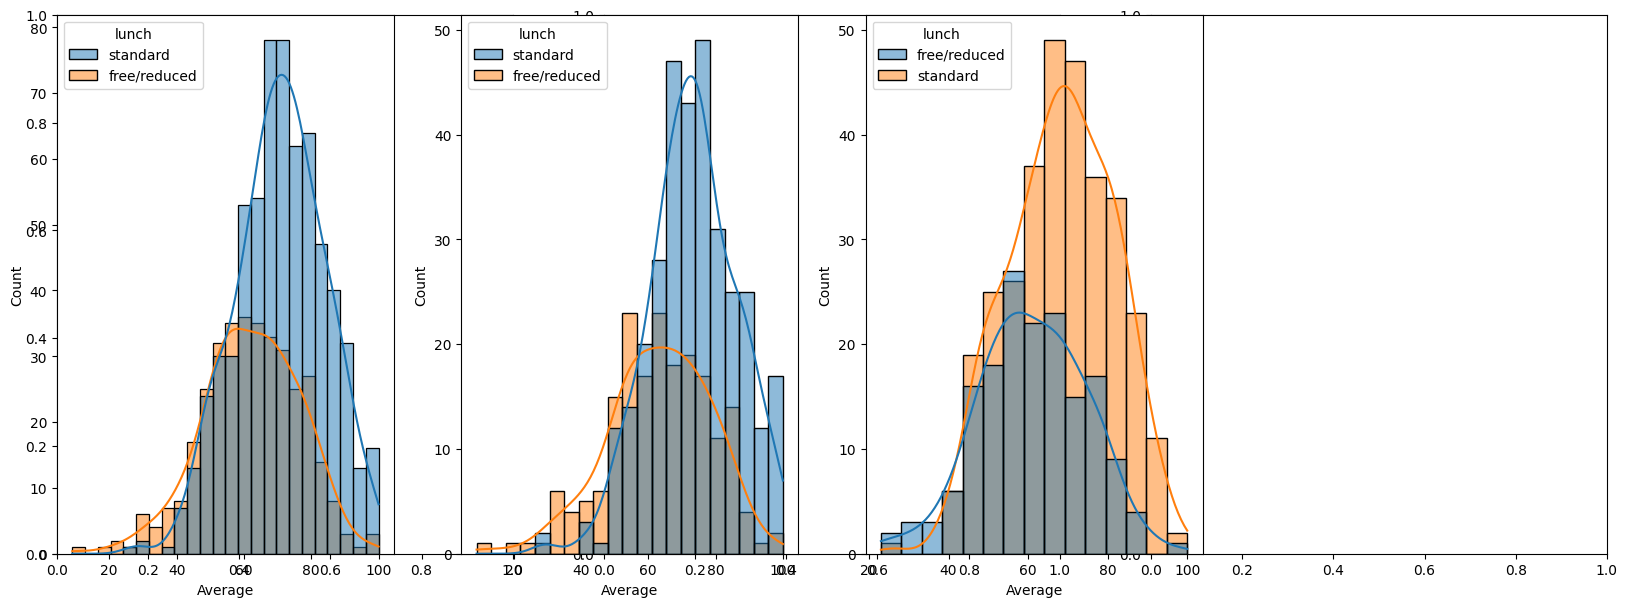

In [50]:
# hue lunch
fig,axis=plt.subplots(1,3,figsize=(20,7))

# for general
plt.subplot(141)
sns.histplot(data=df,x='Average',hue='lunch',kde=True,color='g')

plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],hue='lunch',x='Average',kde=True)

plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],hue='lunch',x='Average',kde=True)


In [51]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total_score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


**Feature extraction**
*   independent- gender,parental education,lunch,test prep
*   dependent-total_score



In [56]:
# encode gender
df['gender'].value_counts()

,count
gender,
female,518
male,482


In [78]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
encoded=ohe.fit_transform(df[['gender','parental level of education','lunch','test preparation course']])
df1=pd.DataFrame(encoded.toarray(),columns=ohe.get_feature_names_out())
df=pd.concat([df,df1],axis=1)

In [82]:
df_copy=df.copy()
columns_drop=['gender','race/ethnicity','parental level of education','lunch','test preparation course','math score','reading score','writing score']
df_copy=df_copy.drop(columns=columns_drop,axis=1)

In [87]:
df_copy=df_copy.drop(columns='Average',axis=1)

In [88]:
df_copy.head()

,Total_score,gender_female,gender_male,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,218,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,247,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,278,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,148,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,229,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


***Model train***

In [85]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

***Split data***

In [103]:
indepedent_feature=df_copy[[feature for feature in df_copy.columns if feature not in ['Total_score']]]
dependent_feature=df_copy[['Total_score']]
X=indepedent_feature
y=dependent_feature

In [104]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [105]:
print("size of x train data set",X_train.shape)
print("size of x test data set",X_test.shape)
print("size of y train data set",y_train.shape)
print("size of y test data set",y_test.shape)


size of x train data set (800, 12)
size of x test data set (200, 12)
size of y train data set (800, 1)
size of y test data set (200, 1)


In [106]:
# train model
regression.fit(X_train,y_train)

LinearRegression()

In [107]:
# slope
regression.coef_

array([[  6.03222161,  -6.03222161,   1.78820943,  12.28078528,
        -13.30711271,   8.76387428,  -0.63342327,  -8.89233301,
        -13.99601986,  13.99601986,  11.94847635, -11.94847635]])

***predict Model***

In [109]:
y_pred_test=regression.predict(X_test)

In [111]:
# performance metrix
from sklearn.metrics import mean_squared_error,mean_absolute_error
print("Mean squared error in model ",mean_squared_error(y_test,y_pred_test))
print("Mean absolute error in model ",mean_absolute_error(y_test,y_pred_test))
print("Root mean squared error is ",np.sqrt(mean_squared_error(y_test,y_pred_test)))

Mean squared error in model  1644.3629202451546
Mean absolute error in model  31.946612664471314
Root mean squared error is  40.55074500234434


In [112]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred_test)
print("accuraccy of model is ",score)

accuraccy of model is  0.1476889611127925


***save model***

In [113]:
import pickle
pickle.dump(regression,open('model.pkl','wb'))